# Session 1 — Single-layer neural networks from scratch

**Session goal:** build simple neural networks using elementary Python operations, train them on small demo datasets, and observe how different parameters of the neural network affect results.

By the end, students should be able to explain:

- What is a single-layer neural network
- Single-layer Neural Network structure/architecture/components for Regression vs. Classfication Problem
- How the neural network can be TRAINED for a particular task (regression or classification)
- Why a single-layer model learns ONLY **linear** relationships




## 0. Initialization

Before building a neural network, we load two Python tools/packages which will help us in building the neural network:

- **NumPy**: handles arrays, matrices, random numbers, and mathematical operations.
- **Matplotlib**: draws plots so we can analyze behavior of different parameters/values.



In [2]:
# Import NumPy and give it the short name np for numerical arrays and mathematical operations.
import numpy as np

# Import the plotting part of Matplotlib and give it the short name plt for drawing graphs.
import matplotlib.pyplot as plt

# Set the random seed so that the same random data is generated every time the notebook is run.
np.random.seed(7)

# Set the default width and height of Matplotlib figures.
plt.rcParams['figure.figsize'] = (7, 4)

# Turn on grid lines in plots to make the figures easier to read.
plt.rcParams['axes.grid'] = True


## 1. Single-Layer Neural Network

A single-layer neural consists of a <span style="color:blue">single-layer</span> of <span style="color:red">neurons</span>.

Let us first see how a neuron works.

A single neuron first forms a weighted sum of its inputs $x_i$:

$$
\begin{aligned}
z &= w_1 x_1 + w_2 x_2 + ... + w_n x_n + b \\
z &=\sum_{i=1}^{n} w_i x_i + b \\
z &=\boldsymbol{w}^T\boldsymbol{x}+b
\end{aligned}
%z
$$

<img src="single_layer_neural_network_Regression.png" width="700">
<!-- ![Single-layer neural network](single_layer_neural_network.png) -->


For the **regression problem**, the prediction may simply be the weighted sum:

$$
\hat{y}=z=\sum_{i=1}^{n} w_i x_i + b
$$

For the **classification problem**, the weighted sum is passed through an <span style="color:blue">activation function</span>, which we will see in a bit






**Objective of the Cell Below**: "Let's first understand how different parameters affect a single neuron's /node's output which only has one input!

<span style="color:red">**Task**: Vary the value of the parameter `w` and `b` using the sliders below and analyze the impact of their increase/decrease on the output </span>
<!-- 
Instructor
- `w` controls the **slope** or importance of the input.
- `b` controls the **vertical shift** or baseline.
 <!-- 

In [3]:
# Create 100 equally spaced x-values from -3 to 3 for drawing straight lines.
x = np.linspace(-3, 3, 100)

# Start a try block because interactive widgets may not be installed in every JupyterLab environment.
try:
    # Import interact for making an interactive function and FloatSlider for decimal sliders.
    from ipywidgets import interact, FloatSlider

    # Define a function that draws a line for a chosen weight w and bias b.
    def show_line(w=1.0, b=0.0):
        # Compute the output y for the current x-values using the equation y = wx + b.
        y = w * x + b

        # Create a new blank figure for this plot.
        plt.figure()

        # Draw the horizontal axis y = 0 to see the coordinate system.
        plt.axhline(0, linewidth=1)

        # Draw the vertical axis x = 0 to  see the coordinate system.
        plt.axvline(0, linewidth=1)

        # Plot the line and show the current values of w and b in the label.
        plt.plot(x, y, label=f'y = {w:.2f}x + {b:.2f}')

        # Limit the vertical axis so that the plot does not zoom too much when sliders change.
        plt.ylim(-6, 6)

        # Show the legend containing the equation of the line.
        plt.legend()

        # Add a title explaining what the figure represents.
        plt.title('Output of Single-layer Neural Network with only one Node/Neuron with a Single Input')

        # Display the completed plot.
        plt.show()

    # Create an interactive version of show_line with sliders for w and b.
    interact(
        show_line,
        w=FloatSlider(min=-3, max=3, step=0.1, value=1),
        b=FloatSlider(min=-3, max=3, step=0.1, value=0)
    );

# Run this fallback code if ipywidgets is missing or disabled.
except Exception as e:
    # Loop over three example values of w and b to show non-interactive lines.
    for w, b in [(-1, 0), (1, 0), (2, 1)]:
        # Draw one example line for the current w and b values.
        plt.plot(x, w * x + b, label=f'w={w}, b={b}')

    # Show the legend for the three example lines.
    plt.legend()

    # Add a title to the fallback plot.
    plt.title('One neuron lines')

    # Display the fallback plot.
    plt.show()


interactive(children=(FloatSlider(value=1.0, description='w', max=3.0, min=-3.0), FloatSlider(value=0.0, descr…

## 2. The <span style="color:blue">Regression</span> Problem

Given a dataset of different inputs and corresponding outputs, sometimes the problem at hand is to guess/predict the output (a $continuous$ value) for a new set of inputs. Such problems are generally known as **Regression** problems. E.g. given a dataset of different house sizes (input) and corresponding house prices(output), find the house price for a house size which is not listed in the given dataset.

Such problems are generally solved by first making a **model** (which could be an equation) which describes well the relationships between the inputs and the output.

Regression models allow us to <span style="color:red">predict</span> a **continuous number**, such as temperature, concentration, pressure, mineral percentage, or plant height.

<img src="regression_problem.png" width="700">

## 3. Demo dataset for regression

Here we first create a small dataset for which we will develop a regression model:

$$
y \approx 2.5x - 0.7 + \text{noise}
$$

<span style="color:red">The model that we will develop for this dataset will not know the true slope and bias. It must learn them from data.</span>




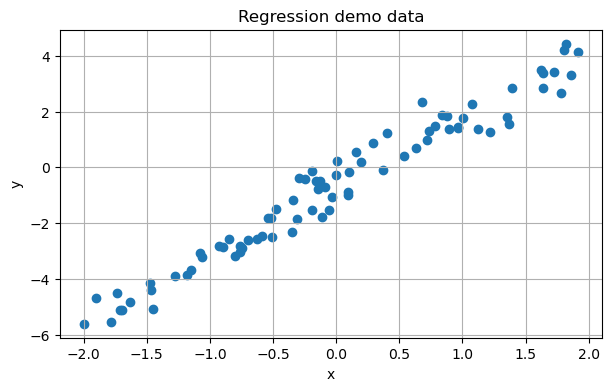

In [4]:
# Store the number of regression examples we want to create.
N = 80

# Generate N random input values between -2 and 2 and store them as a column vector with shape (N, 1).
X = np.random.uniform(-2, 2, size=(N, 1))

# Generate the target values using a hidden true rule plus random noise.
#X[:, 0] means take all rows and only the first column
y = 2.5 * X[:, 0] - 0.7 + np.random.normal(0, 0.6, size=N)

# Reshape y from shape (N,) to shape (N, 1) so it behaves like a column vector.
y = y.reshape(-1, 1)

# Draw a scatter plot of the input x-values and target y-values.
plt.scatter(X[:, 0], y[:, 0])

# Label the horizontal axis as x.
plt.xlabel('x')

# Label the vertical axis as y.
plt.ylabel('y')

# Add a title to explain the plot.
plt.title('Regression demo data')

# Display the plot.
plt.show()


## 4. Manual <span style="color:red">training</span> for linear regression

The purpose of **training** is to come up with a **good <span style="color:red">model</span>** for our concerned problem (e.g. regression in this case)

The model (neural network) starts with some initial values of the <span style="color:red">network parameters</span>. The initial values are (<span style="color:red">often zero or randomly chosen </span>)

$$
\begin{aligned}
z_{ini} &=\boldsymbol{w}^T_{ini}\boldsymbol{x}+b_{ini} \\
        &=\boldsymbol{x}^T\boldsymbol{w}_{ini}+b_{ini}
\end{aligned}
$$

**Generally the performance of (regression) model based on the initial values is not good**. 

<span style="color:red">How can we decide if a given model is good or bad?</span>


The **<span style="color:blue">loss</span>** measures how wrong the predictions are. For *regression* we use **mean squared error**:
$$
\begin{aligned}
L &=\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2 \\
 &=\frac{1}{N}\sum_{i=1}^{N}((\boldsymbol{x}^T\boldsymbol{w}+b)-y_i)^2 \\
 &=\frac{1}{N}(\boldsymbol{\hat{y}}-\boldsymbol{y})^{T}(\boldsymbol{\hat{y}}-\boldsymbol{y}) \\
 &=\frac{1}{N}((X\boldsymbol{w}+b)-\boldsymbol{y})^{T}(X\boldsymbol{w}+b)-\boldsymbol{y})
\end{aligned}
$$



During **training**, we try to find *better* of the network parameters ($w$,$b$), such that a (regression) model based on new parameter values has better performance. Model training generally comprises of a number of iterations. In each iteration, the parameters are updated as:

$$
\begin{aligned}
\boldsymbol{w}_{new}&=\boldsymbol{w}_{old}+\underbrace{\Delta\boldsymbol{w}}_{\text{change in $\boldsymbol{w}$ }} \\
b_{new}&=b_{old}+\underbrace{\Delta b}_{\text{change in $b$}}
\end{aligned}
$$

where

$$
\Delta\boldsymbol{w}=\underbrace{\eta}_{\text{\textcolor{red}{learning rate}}}\times \underbrace{\nabla_{\boldsymbol{w}} L}_{\text{\textcolor{red}{gradient} of Loss wrt $\boldsymbol{w}$}}
$$
and
$$
\Delta b=\underbrace{\eta}_{\text{learning rate}}\times \underbrace{\nabla_{b} L}_{\text{gradient of Loss wrt $b$}}
$$


For our simple model, the gradients are:

$$
\nabla_{\boldsymbol{w}} L = \frac{\partial L}{\partial \boldsymbol{w}}=\frac{2}{N}X^T(\hat{\boldsymbol{y}}-\boldsymbol{y})
$$

$$
\nabla_{b} L = \frac{\partial L}{\partial b}=\frac{2}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)
$$


We now execute the training of our simple single-layer neural-network for the regression problem using the following looP:
<img src="training_loop.png" width="700">

learned w: 2.4390759061618215
learned b: -0.6933352493095415
final loss: 0.2731521756866794


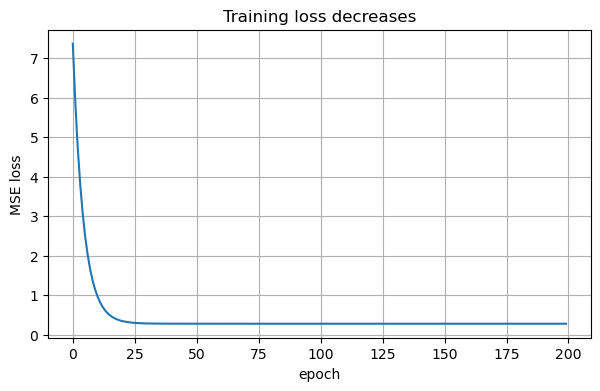

In [10]:
# Define a function that trains a linear regression model from scratch.
# X=inputs matrix, y = output vector, lr = learning rate (scalar), epochs = no. of iterations
def train_linear_regression(X, y, lr=0.05, epochs=200):
    # Read the number of examples N and the number of input features D from the shape of X. (80 by 1)
    N, D = X.shape
    #print(X.shape)

    # Create a weight column vector initialized to zeros with one weight per input feature.
    w = np.zeros((D, 1))

    # Create the bias term initialized to zero.
    b = 0.0

    # Create an empty list to store the loss value after each training step.
    losses = []

    # Repeat the training process for the requested number of epochs.
    for epoch in range(epochs):
        # Compute predictions using the matrix equation y_hat = Xw + b.
        # symbol @ is used for matrix multiplication
        y_hat = X @ w + b

        # Compute prediction error by subtracting true target values from predicted values.
        error = y_hat - y

        # Compute mean squared error loss by averaging squared errors.
        loss = np.mean(error ** 2)

        # Save the current loss so we can plot the learning curve later.
        losses.append(loss)

        # Compute the gradient of the loss with respect to the weights.
        dw = (2 / N) * X.T @ error

        # Compute the gradient of the loss with respect to the bias.
        db = (2 / N) * np.sum(error)

        # Update the weights by moving opposite to the gradient direction.
        w = w - lr * dw

        # Update the bias by moving opposite to the gradient direction.
        b = b - lr * db

    # Return the learned weights, learned bias, and loss history as a NumPy array.
    return w, b, np.array(losses)

# Train the regression model on our demo data using learning rate 0.05 and 200 epochs.
w, b, losses = train_linear_regression(X, y, lr=0.05, epochs=200)

# Print the learned slope value for the first and only input feature.
#Flatten the array into one dimension using ravel() and then take the first element using [0].
print('learned w:', w.ravel()[0])

# Print the learned bias value.
print('learned b:', b)

# Print the final training loss.
# In Python -1 index value represaents last element
print('final loss:', losses[-1])

# Plot the loss values across epochs to see whether training improved the model.
plt.plot(losses)

# Label the horizontal axis as epoch.
plt.xlabel('epoch')

# Label the vertical axis as MSE loss.
plt.ylabel('MSE loss')

# Add a title explaining that the loss should decrease during training.
plt.title('Training loss decreases')

# Display the loss curve.
plt.show()


**<span style="color:red">Comment on whether or not the learned parameter values are good or bad? and why?</span>**


## 4. Plot the learned regression line

After training, we draw the learned line on top of the original data.

A good learned line should pass through the middle of the noisy cloud of points.




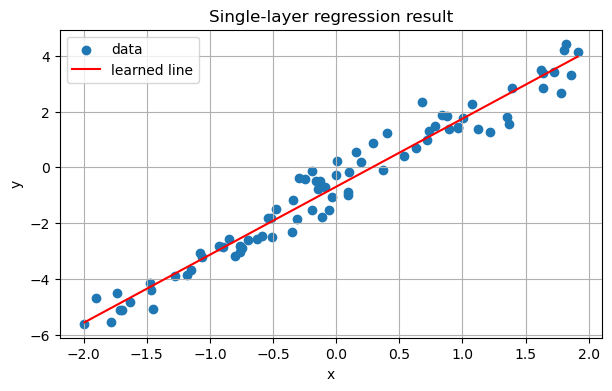

In [6]:
# Create 100 x-values between the minimum and maximum observed training x-values.
# reshape() here converts a row-vector to a column vector. -1 indicates only 1 column desired, no. of rows is automatically calculated
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Use the learned model to predict y-values for the line.
y_line = x_line @ w + b

# Draw the original noisy data points.
plt.scatter(X[:, 0], y[:, 0], label='data')

# Draw the learned regression line.
plt.plot(x_line[:, 0], y_line[:, 0], label='learned line', color='red')

# Label the horizontal axis as x.
plt.xlabel('x')

# Label the vertical axis as y.
plt.ylabel('y')

# Add a title to the plot.
plt.title('Single-layer regression result')

# Show the legend for data and learned line.
plt.legend()

# Display the plot.
plt.show()


## 5. Experiment with learning rate and epochs

The **learning rate** controls **<span style="color:red">step size </span>**.

- Too small: learning is slow.
- Good value: loss decreases smoothly.
- Too large: training may jump around or diverge.

The **number of epochs** controls how many times the model updates its parameters.

<img src="learning_rate_plots.png" width="700">

<span style="color:red">**Task**: Vary the value of the parameters 'learning rate' and 'epochs'` using the sliders below and analyze the impact of their increase/decrease on the *learning* of the network parameters ($\boldsymbol{w}$,$b$) </span>


In [7]:
# Start a try block because interactive widgets may not be installed in every JupyterLab environment.
try:
    # Import interact for interactive controls, FloatLogSlider for learning rate, and IntSlider for epochs.
    from ipywidgets import interact, FloatLogSlider, IntSlider

    # Define a function that retrains the model whenever slider values change.
    def experiment_regression(lr=0.05, epochs=200):
        # Train a fresh regression model using the selected learning rate and number of epochs.
        w, b, losses = train_linear_regression(X, y, lr=lr, epochs=epochs)

        # Create evenly spaced x-values for drawing the learned line.
        x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

        # Predict y-values for the line using the learned model.
        y_line = x_line @ w + b

        # Create a wider figure so we can show two plots side by side.
        plt.figure(figsize=(12, 4))

        # Select the first subplot for the data and learned line.
        plt.subplot(1, 2, 1)

        # Draw the training data points.
        plt.scatter(X[:, 0], y[:, 0])

        # Draw the learned regression line.
        plt.plot(x_line[:, 0], y_line[:, 0], color='red')

        # Show learned parameter values in the subplot title.
        plt.title(f'w={w.ravel()[0]:.2f}, b={b:.2f}')

        # Select the second subplot for the loss curve.
        plt.subplot(1, 2, 2)

        # Plot the loss history.
        plt.plot(losses)

        # Show the final loss value in the subplot title.
        plt.title(f'final loss={losses[-1]:.3f}')

        # Label the horizontal axis as epoch.
        plt.xlabel('epoch')

        # Display both subplots.
        plt.show()

    # Create interactive sliders for learning rate and epochs.
    interact(
        experiment_regression,
        lr=FloatLogSlider(value=0.05, base=10, min=-3, max=0, step=0.1),
        epochs=IntSlider(value=200, min=1, max=1000, step=10)
    );

# Run this fallback if ipywidgets is unavailable.
except Exception:
    # Tell the user how to enable the interactive sliders.
    print('Install ipywidgets to use the interactive sliders.')


interactive(children=(FloatLogSlider(value=0.05, description='lr', max=0.0, min=-3.0), IntSlider(value=200, de…

## 6. The <span style="color:blue">Classification</span> Problem

Given a dataset of different inputs and their corresponding **classes/categories**, sometimes the problem at hand is to guess/predict the*class/category (**discrete** set of value) for a new set of inputs. Such problems are generally known as **Classification** problems. E.g. given a dataset of different images of cats or dogs with a label ('cat' or 'dog') attached to each image, determine automatically the label for a new image.

Such problems are also solved by first making a **model** which help determine the **decision boudary** separating different classes/categories (see figure below).


<img src="classification_problem.png" width="700">

The *decision boundary* is given by all inputs $\boldsymbol{x}$ satisfying
$$
\boldsymbol{w}^T\boldsymbol{x}+b=0 
$$
Every input on one side of the boundary would satisfy
$$
\boldsymbol{w}^T\boldsymbol{x}+b>0 
$$
and every input on the other side would satisfy
$$
\boldsymbol{w}^T\boldsymbol{x}+b<0 
$$
thereby helping us determine the class/category corresponding to a given input

## 7. Single-layer Neural Network for classification

Classification means predicting a **class/category**. In <span style="color:red">binary</span> classification, the target is usually 0 or 1.

As in Regression, a single-layer neural-network acting as a classifier first computes:

$$
z=\boldsymbol{w}^T\boldsymbol{x}+b
$$

However, this gives us a continuous value *z*. To map this value to a particular class/category, *z* is converted into a <span style="color:red">probability</span> using an **activation function** which squeezes any number into a range e.g. 0 to 1 for output probability. There are many types of activation functions (see figure below)

<img src="activation_functions.png" width="700">
  

The output of the activation function can then be used to decide the category/class (class 0 or class 1 for binary classification case) for the inputs based on a **Decision rule**, such as, the model predicts class 1 where probability is high and class 0 where probability is low:

$$
\hat{y}=\begin{cases}
1, & p\geq 0.5 \\
0, & p<0.5
\end{cases}
$$

The overall structure of the single-layer neural-network for the classification problem then becomes as follows (<span style="color:red">Note the difference with respect to the NN structure for the Regression problem</span>):

<img src="single_layer_neural_network_Classification.png" width="700">

 This type of Single-layer NN for Binary Classification is also known as **Logistic Regression classifier**



## 8. Creating Demo Dataset for Binary Classification

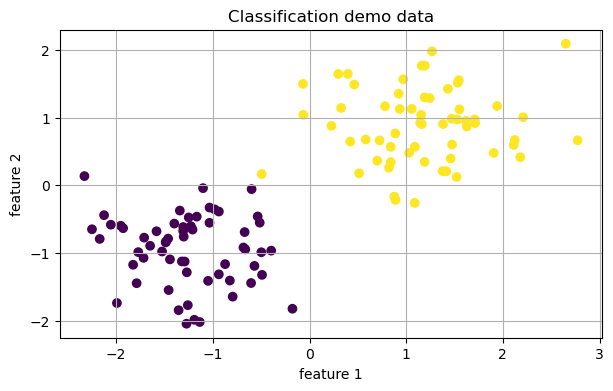

In [8]:


# Store the number of classification examples we want to create.
N = 120

# Generate class 0 points around the location (-1.2, -1.0).
#generates points for 2D gaussian distribution
# np.random.normal(loc, scale, size) where 
#loc: mean (center) of the distribution, scale: standard deviation (spread), size: shape of the output array
#The // operator in Python represents floor division
X0 = np.random.normal(loc=[-1.2, -1.0], scale=0.55, size=(N // 2, 2))

# Generate class 1 points around the location (1.2, 1.0).
X1 = np.random.normal(loc=[1.2, 1.0], scale=0.55, size=(N // 2, 2))

# Stack class 0 and class 1 input points into one input array.
Xc = np.vstack([X0, X1])

# Create labels: zeros for class 0 and ones for class 1.
yc = np.vstack([np.zeros((N // 2, 1)), np.ones((N // 2, 1))])

# Draw the two-dimensional data points and color them by class label.
plt.scatter(Xc[:, 0], Xc[:, 1], c=yc[:, 0])

# Label the horizontal axis as feature 1.
plt.xlabel('feature 1')

# Label the vertical axis as feature 2.
plt.ylabel('feature 2')

# Add a title to the plot.
plt.title('Classification demo data')

# Display the plot.
plt.show()


## 9. Train a single-layer *classifier*

For classification, mean squared error is usually not the best choice for the Loss function. We use **binary cross-entropy**:

Binary cross-entropy is preferred because it directly measures the quality of predicted probabilities, heavily penalizes confident mistakes, and provides more informative gradients for training classifiers. In short, it is <span style="color:blue">better suited loss function for the classification problem </span>.

$$
L_{CE}=-\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right]
$$

where $L_{CE}$ represents the 'Cross-Entropy' Loss function, $y_i$ and $p_i$ represent true label/class (0 or 1) and the predicted probability for the $i$th example in the training dataset

For example,, suppose the true label is 1:
| Predicted probability |  MSE | Binary Cross-Entropy |
| --------------------: | ---: | -------------------: |
|                  0.90 | 0.01 |                0.105 |
|                  0.60 | 0.16 |                0.511 |
|                  0.10 | 0.81 |                2.303 |
|                  0.01 | 0.98 |                4.605 |


For sigmoid plus binary cross-entropy, the gradient becomes especially simple:

$$
dz=\frac{\partial L_{CE}}{\partial z} = \frac{p-y}{N}
$$
Note that $p-y$ is just the prediction error e.g. for y (true label)=1 and predicted probability = 1, gradient is 0, so no update is needed

Then:

$$
\frac{\partial L_{CE}}{\partial \boldsymbol{w}}=X^Tdz,\qquad
\frac{\partial L_{CE}}{\partial b}=\sum_i dz_i
$$




w: [2.21725428 1.76616528] b: 0.21411896784569895 final loss: 0.03983600773593896


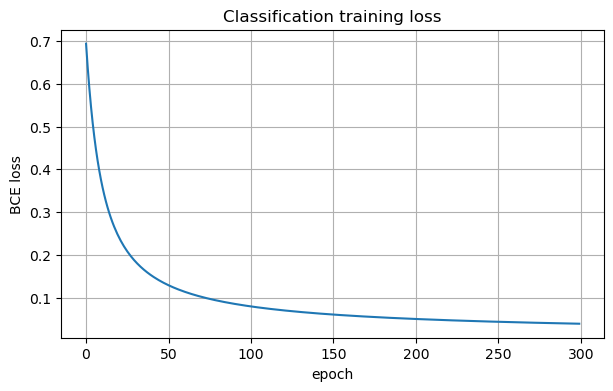

In [11]:
# Define the sigmoid function that converts any score into a value between 0 and 1.
def sigmoid(z):
    # Apply the sigmoid formula element-by-element to z.
    return 1 / (1 + np.exp(-z))

# Define binary cross-entropy loss for binary classification.
def binary_cross_entropy(p, y, eps=1e-9):
    # Clip probabilities so log(0) does not occur.
    p = np.clip(p, eps, 1 - eps)

    # Compute the average binary cross-entropy loss.
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

# Define a function that trains a Single-layer Binary classifier from scratch.
def train_singlelayer_binary_classifier(X, y, lr=0.1, epochs=300):
    # Read the number of examples N and the number of input features D from X.
    N, D = X.shape

    # Create a weight column vector initialized to zeros with one weight per input feature.
    w = np.zeros((D, 1))

    # Create the bias term initialized to zero.
    b = 0.0

    # Create an empty list to store the loss value after each epoch.
    losses = []

    # Repeat the training process for the requested number of epochs.
    for epoch in range(epochs):
        # Compute the linear score z = Xw + b.
        z = X @ w + b

        # Convert the score into a probability using sigmoid.
        p = sigmoid(z)

        # Compute binary cross-entropy loss between predicted probabilities and true labels.
        loss = binary_cross_entropy(p, y)

        # Save the current loss for later plotting.
        losses.append(loss)

        # Compute the gradient with respect to z for sigmoid plus binary cross-entropy.
        dz = (p - y) / N

        # Compute the gradient of the loss with respect to the weights.
        dw = X.T @ dz

        # Compute the gradient of the loss with respect to the bias.
        db = np.sum(dz)

        # Update the weights by moving opposite to the gradient direction.
        w = w - lr * dw

        # Update the bias by moving opposite to the gradient direction.
        b = b - lr * db

    # Return the learned weights, learned bias, and loss history.
    return w, b, np.array(losses)

# Train the classification model on our demo data.
w_cls, b_cls, losses_cls = train_singlelayer_binary_classifier(Xc, yc, lr=0.1, epochs=300)

# Print the learned weights, bias, and final loss.
print('w:', w_cls.ravel(), 'b:', b_cls, 'final loss:', losses_cls[-1])


# Plot the classification loss values across epochs.
plt.plot(losses_cls)

# Label the horizontal axis as epoch.
plt.xlabel('epoch')

# Label the vertical axis as binary cross-entropy loss.
plt.ylabel('BCE loss')

# Add a title explaining the plot.
plt.title('Classification training loss')

# Display the loss curve.
plt.show()


## 10. Visualize the decision boundary

The model predicts class 1 where probability is high and class 0 where probability is low.

The line where probability equals 0.5 is the **decision boundary**.

For a single-layer model with two input features, this boundary is a straight line.


<span style="color:red"> **Task**:Observe the decision boundary below and comment on the goodness of our obtained model along with reasoning </span>



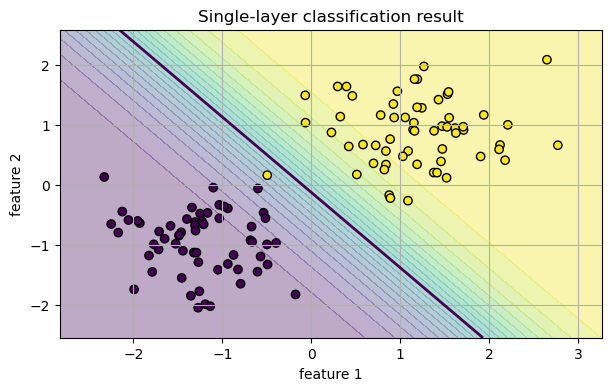

In [12]:
# Define a helper function to plot the learned decision boundary.
def plot_decision_boundary(X, y, w, b, title='Decision boundary'):
    # Find the smallest and largest values for feature 1 and add a small margin.
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5

    # Find the smallest and largest values for feature 2 and add a small margin.
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create a grid of many feature-1 and feature-2 values covering the plot area.
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

    # Convert the grid into a two-column array so the model can process it.
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict probabilities for all grid points and reshape them back into grid form.
    probs = sigmoid(grid @ w + b).reshape(xx.shape)

    # Draw the probability background as colored filled contours.
    plt.contourf(xx, yy, probs, levels=20, alpha=0.35)

    # Draw the decision boundary where probability equals 0.5.
    plt.contour(xx, yy, probs, levels=[0.5], linewidths=2)

    # Draw the original data points on top of the probability background.
    plt.scatter(X[:, 0], X[:, 1], c=y[:, 0], edgecolor='k')

    # Add a title to the plot.
    plt.title(title)

    # Label the horizontal axis as feature 1.
    plt.xlabel('feature 1')

    # Label the vertical axis as feature 2.
    plt.ylabel('feature 2')

    # Display the completed decision boundary plot.
    plt.show()

# Plot the learned decision boundary for the classification data.
plot_decision_boundary(Xc, yc, w_cls, b_cls, 'Single-layer classification result')




## 11. Test accuracy

**Accuracy** answers this question:

> <span style="color:blue"> Out of all examples, how many of them were correctly classified by our Classifier?</span>

$$
\text{Accuracy}=\frac{\text{number of correct predictions}}{\text{total number of predictions}}
$$

For each example:

1. Compute probability `p`.
2. Convert `p` into class prediction using threshold 0.5.
3. Compare predicted class with true class.




In [13]:
# Compute predicted probabilities for all classification examples.
p = sigmoid(Xc @ w_cls + b_cls)

# Convert probabilities into class predictions using 0.5 as the cutoff.
y_pred = (p >= 0.5).astype(int)

# Compute accuracy as the average of correct predictions.
accuracy = np.mean(y_pred == yc)

# Print the accuracy rounded to three decimal places.
print(f'Accuracy: {accuracy:.3f}')

# Loop through the first 10 examples to inspect individual predictions.
for i in range(10):
    # Print the true label, predicted probability, and predicted class for one example.
    print(f'true={int(yc[i, 0])}, probability={p[i, 0]:.3f}, predicted={int(y_pred[i, 0])}')


Accuracy: 0.992
true=0, probability=0.002, predicted=0
true=0, probability=0.003, predicted=0
true=0, probability=0.022, predicted=0
true=0, probability=0.229, predicted=0
true=0, probability=0.005, predicted=0
true=0, probability=0.143, predicted=0
true=0, probability=0.007, predicted=0
true=0, probability=0.032, predicted=0
true=0, probability=0.072, predicted=0
true=0, probability=0.011, predicted=0


## 12. Mini exercises

1. Change the regression noise level from `0.6` to `1.2`. What happens to the learned line?
2. Try `lr = 1.0` in regression. Does the loss still decrease smoothly?
3. Move the two classification clusters closer together by changing their centers from `[-1.2, -1.0]` and `[1.2, 1.0]` to `[-0.5, -0.5]` and `[0.5, 0.5]`. What happens to accuracy?
4. Change the number of epochs in classification from `300` to `30`. Does the boundary still look good?




## 13. Key takeaways of Session 1: 

- A **Single-layer Neural-Network (SSNN)** with one Node/Neuron is the <span style="color:blue">simplest of Neural-Networks </span>
- A **node/neuron** <span style="color:blue">produces its output from a weighted sum of its inputs</span>
- An SSNN can tackle the **Regression problem** as well as the **Classification problem**
- The performance of a NN is improved via the process of **training**
- An <span style="color:blue">SSNN can ONLY learn a **linear rule**</span>. 
  It cannot easily learn curved or complex decision boundaries.